# 00 — Exploratory Data Analysis

Produces all EDA figures for the report (Section 4.1).
Saves to `../report/figures/` with descriptive filenames.

| Section | Figure | Purpose |
|---------|--------|---------|
| 2 | `total_vehicles_distribution.png` | Target variable skewness |
| 3 | `country_fleet_overview.png` | Country-level fleet (Fig 4.1) |
| 4 | `data_sparsity.png` | Config coverage & sparsity (Fig 4.2) |
| 5 | `cold_start_proportion.png` | Cold-start gap analysis (Fig 4.3) |
| 6 | `segment_energy_heatmap.png` | Segment × energy heatmap (Fig 4.8) |
| 7 | `energy_mix_comparison.png` | Stacked energy mix by country |
| 8 | `ev_adoption_by_country.png` | EV/hybrid adoption gap |
| 9 | `fleet_age_comparison.png` | Fleet age: Turkey vs Europe |
| 10 | `country_similarity_turkey.png` | Cosine similarity to Turkey |
| 11 | `top_segments_turkey_vs_europe.png` | Top segments comparison |

## 1) Imports + Data Load

In [1]:
try:
    import pandas as _pd
    _pd.options.future.infer_string = False
except AttributeError:
    pass

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings("ignore")

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TR_COLOR  = '#E87722'   # Michelin orange — Turkey
EU_COLOR  = '#4472C4'   # blue — Europe
FIG_DIR   = '../report/figures/'
os.makedirs(FIG_DIR, exist_ok=True)

# ── Load data ────────────────────────────────────────────────────────────────
train = pd.read_csv('../data/EM_LYON_train_set_20260206.csv', sep=';')
test  = pd.read_csv('../data/EM_LYON_test_set_20260206.csv',  sep=',')

# Normalise country code
train['country_iso'] = train['country_iso'].astype(str).str.strip().str.upper()
test['country_iso']  = test['country_iso'].astype(str).str.strip().str.upper()

# Drop 66 NaN rows in key categorical columns
key_cols = ['car_maker_name', 'car_segment_name', 'car_type_name', 'energy', 'body_style']
train = train.dropna(subset=key_cols).copy()

# Convenience splits
tr = train[train['country_iso'] == 'TR'].copy()
eu = train[train['country_iso'] != 'TR'].copy()

# Age mapping
age_map = {
    'Less than 1 year old': 0.5,
    '1 year old': 1.0,
    '2 years old': 2.0,
    '3 to 5 years old': 4.0,
    '6 to 10 years old': 8.0,
    '11 years and older': 12.0,
}

print(f'Train shape  : {train.shape}')
print(f'Turkey rows  : {len(tr):,}   |  EU rows: {len(eu):,}')
print(f'Countries    : {train["country_iso"].nunique()} — {sorted(train["country_iso"].unique())}')
print(f'Test  shape  : {test.shape}')
print(f'\nColumn dtypes:')
print(train.dtypes)
print(f'\nMissing (after drop): {train.isnull().sum().sum()}')

Train shape  : (91697, 10)
Turkey rows  : 6,845   |  EU rows: 84,852
Countries    : 11 — ['AT', 'BA', 'BY', 'ES', 'HR', 'HU', 'IE', 'PL', 'RO', 'SK', 'TR']
Test  shape  : (254, 11)

Column dtypes:
country_iso          object
country_name         object
car_maker_name       object
car_segment_name     object
car_type_name        object
energy               object
code_age             object
body_style           object
year_stamp            int64
total_vehicles      float64
dtype: object

Missing (after drop): 0


## 2) Target Variable: `total_vehicles` Distribution

Saved: ../report/figures/total_vehicles_distribution.png


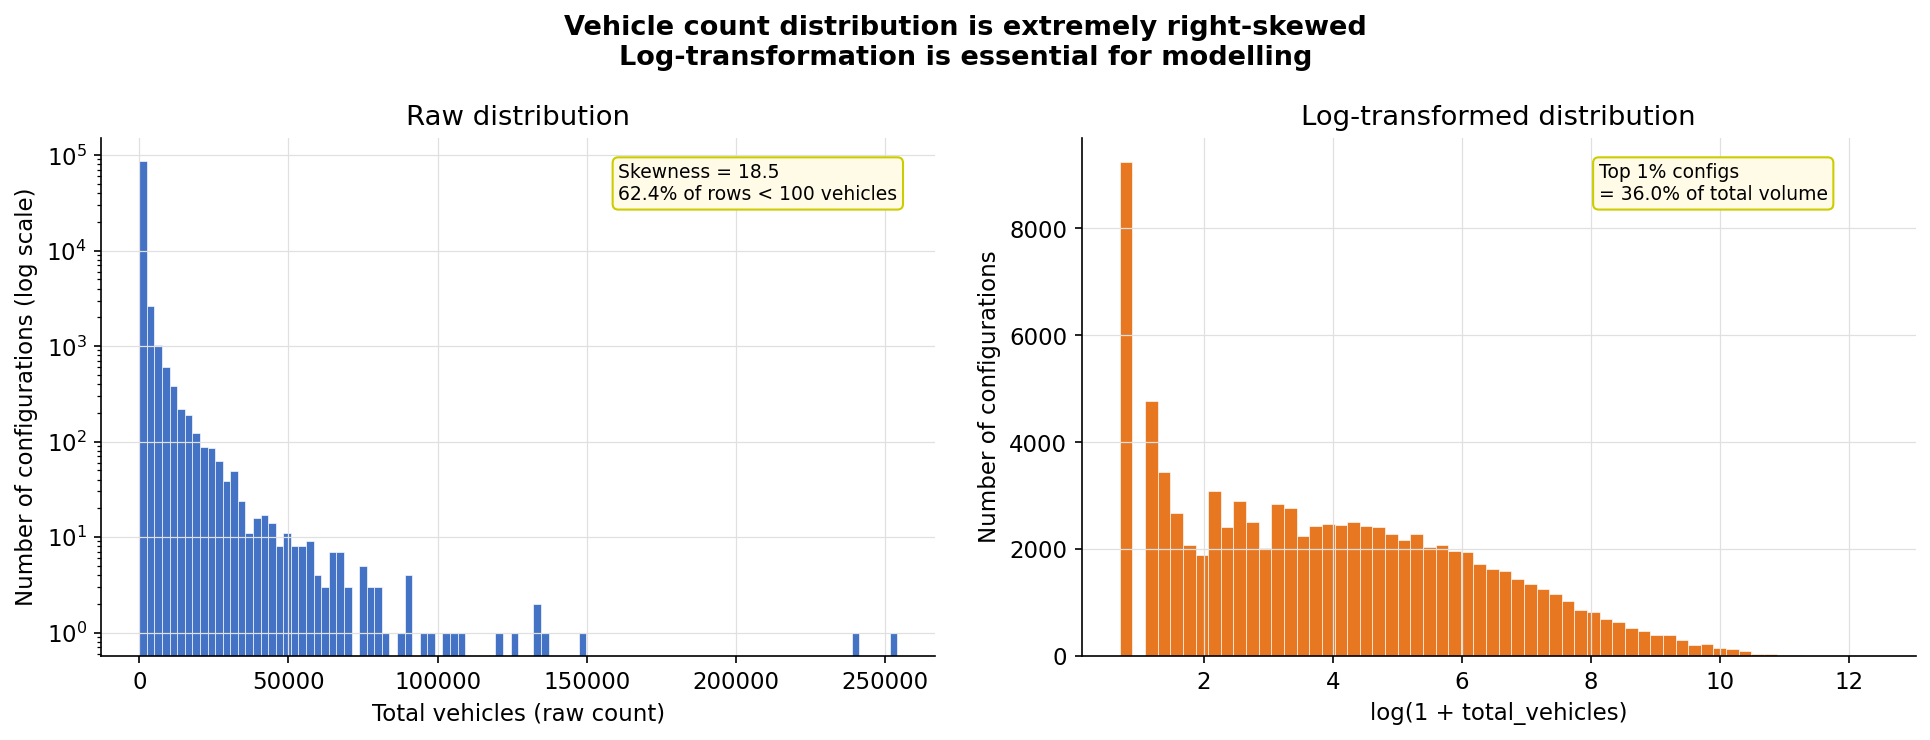

In [2]:
tv = train['total_vehicles']
skewness   = tv.skew()
pct_lt100  = (tv < 100).mean() * 100
top1_share = tv[tv >= tv.quantile(0.99)].sum() / tv.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — raw histogram (log y-axis)
ax = axes[0]
ax.hist(tv, bins=100, color=EU_COLOR, edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlabel('Total vehicles (raw count)')
ax.set_ylabel('Number of configurations (log scale)')
ax.set_title('Raw distribution')
ax.annotate(f'Skewness = {skewness:.1f}\n{pct_lt100:.1f}% of rows < 100 vehicles',
            xy=(0.62, 0.88), xycoords='axes fraction',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='#fffbe6', ec='#cccc00'))

# Right — log1p histogram
ax = axes[1]
ax.hist(np.log1p(tv), bins=60, color=TR_COLOR, edgecolor='white', linewidth=0.3)
ax.set_xlabel('log(1 + total_vehicles)')
ax.set_ylabel('Number of configurations')
ax.set_title('Log-transformed distribution')
ax.annotate(f'Top 1% configs\n= {top1_share:.1f}% of total volume',
            xy=(0.62, 0.88), xycoords='axes fraction',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='#fffbe6', ec='#cccc00'))

fig.suptitle('Vehicle count distribution is extremely right-skewed\n'
             'Log-transformation is essential for modelling', fontsize=13, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR + 'total_vehicles_distribution.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 3) Country-Level Fleet Overview  ← Fig 4.1

Saved: ../report/figures/country_fleet_overview.png


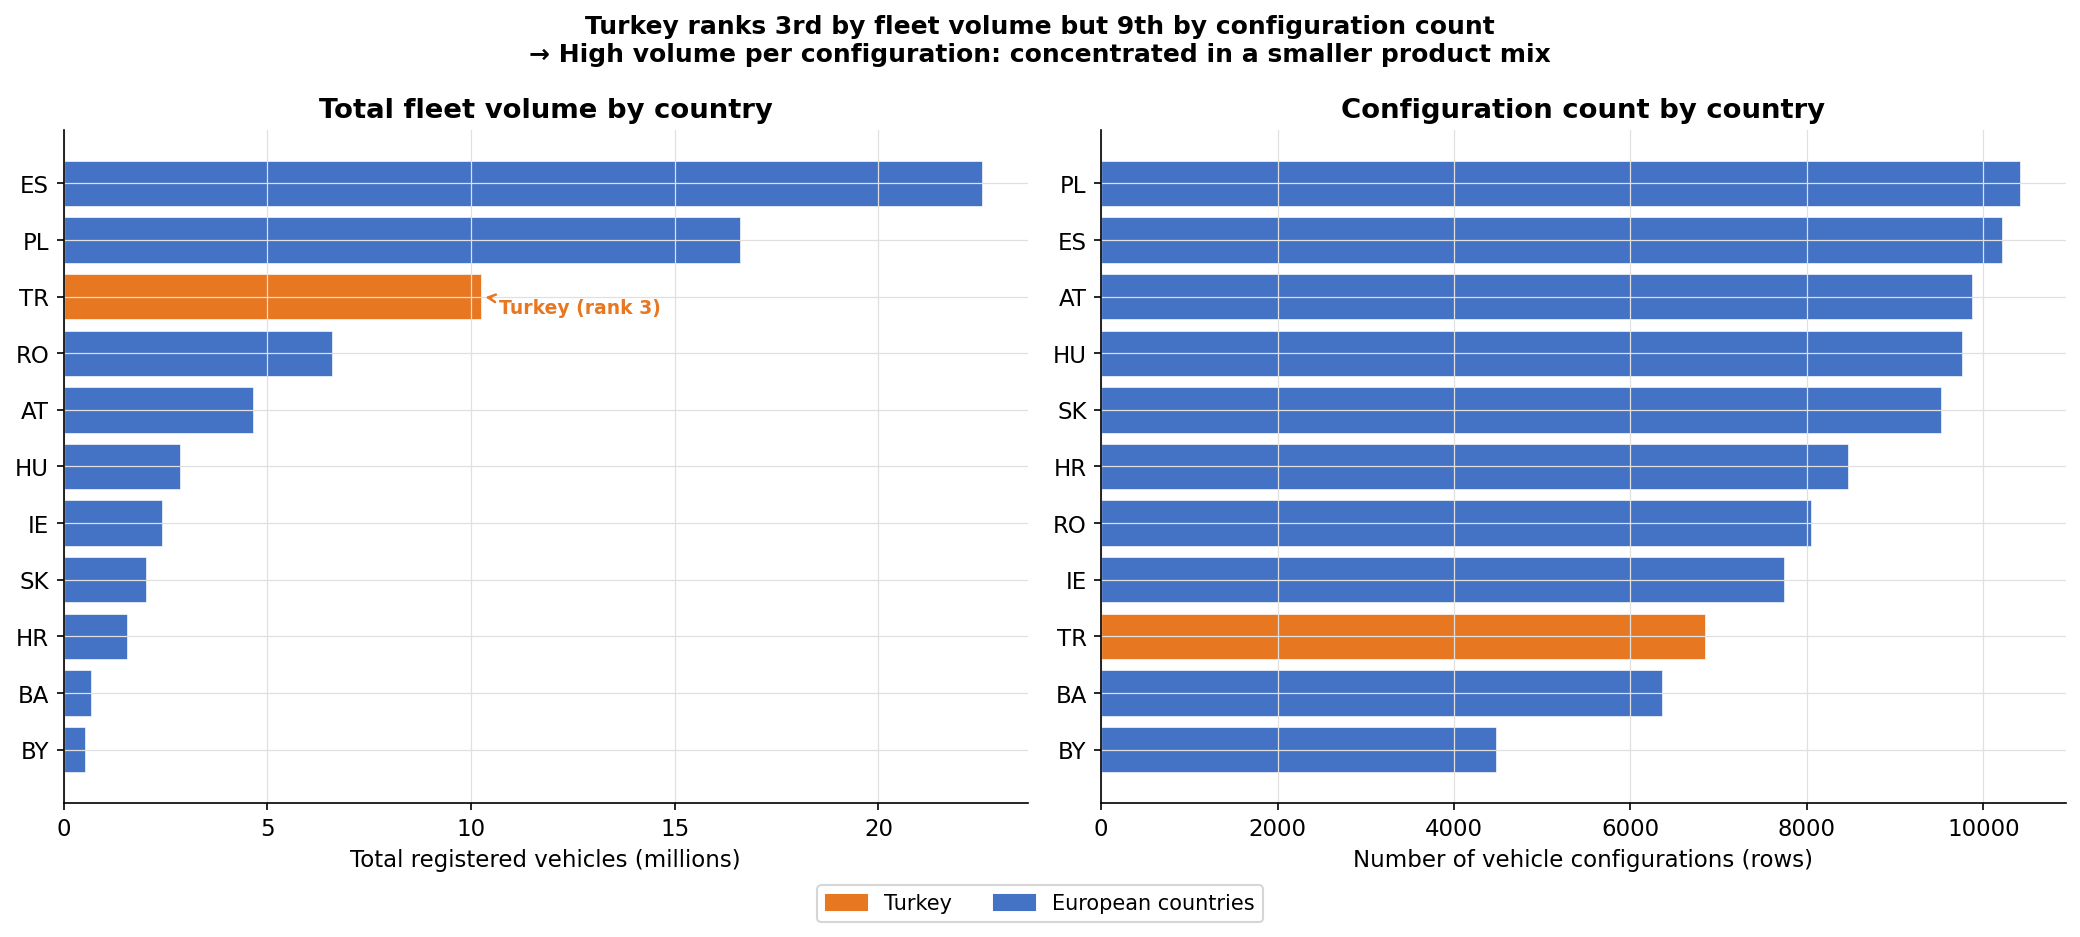

In [3]:
country_vol  = train.groupby('country_iso')['total_vehicles'].sum().sort_values(ascending=True)
country_rows = train.groupby('country_iso').size().sort_values(ascending=True)

def bar_colors(index, highlight='TR', c_hi=TR_COLOR, c_lo=EU_COLOR):
    return [c_hi if c == highlight else c_lo for c in index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — total fleet volume
ax = axes[0]
ax.barh(country_vol.index, country_vol.values / 1e6,
        color=bar_colors(country_vol.index), edgecolor='white', linewidth=0.3)
ax.set_xlabel('Total registered vehicles (millions)')
ax.set_title('Total fleet volume by country', fontweight='bold')
# Annotate Turkey rank
tr_rank_vol = len(country_vol) - list(country_vol.index).index('TR')
ax.annotate(f'Turkey (rank {tr_rank_vol})',
            xy=(country_vol['TR'] / 1e6, list(country_vol.index).index('TR')),
            xytext=(country_vol['TR'] / 1e6 + country_vol.max() * 0.02 / 1e6,
                    list(country_vol.index).index('TR') - 0.3),
            fontsize=9, color=TR_COLOR, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TR_COLOR, lw=1.2))

# Right — row count
ax = axes[1]
ax.barh(country_rows.index, country_rows.values,
        color=bar_colors(country_rows.index), edgecolor='white', linewidth=0.3)
ax.set_xlabel('Number of vehicle configurations (rows)')
ax.set_title('Configuration count by country', fontweight='bold')

# Shared legend
patches = [
    mpatches.Patch(color=TR_COLOR, label='Turkey'),
    mpatches.Patch(color=EU_COLOR, label='European countries'),
]
fig.legend(handles=patches, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04),
           frameon=True, fontsize=10)

fig.suptitle('Turkey ranks 3rd by fleet volume but 9th by configuration count\n'
             '→ High volume per configuration: concentrated in a smaller product mix',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR + 'country_fleet_overview.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 4) Data Sparsity & Configuration Coverage  ← Fig 4.2

Saved: ../report/figures/data_sparsity.png


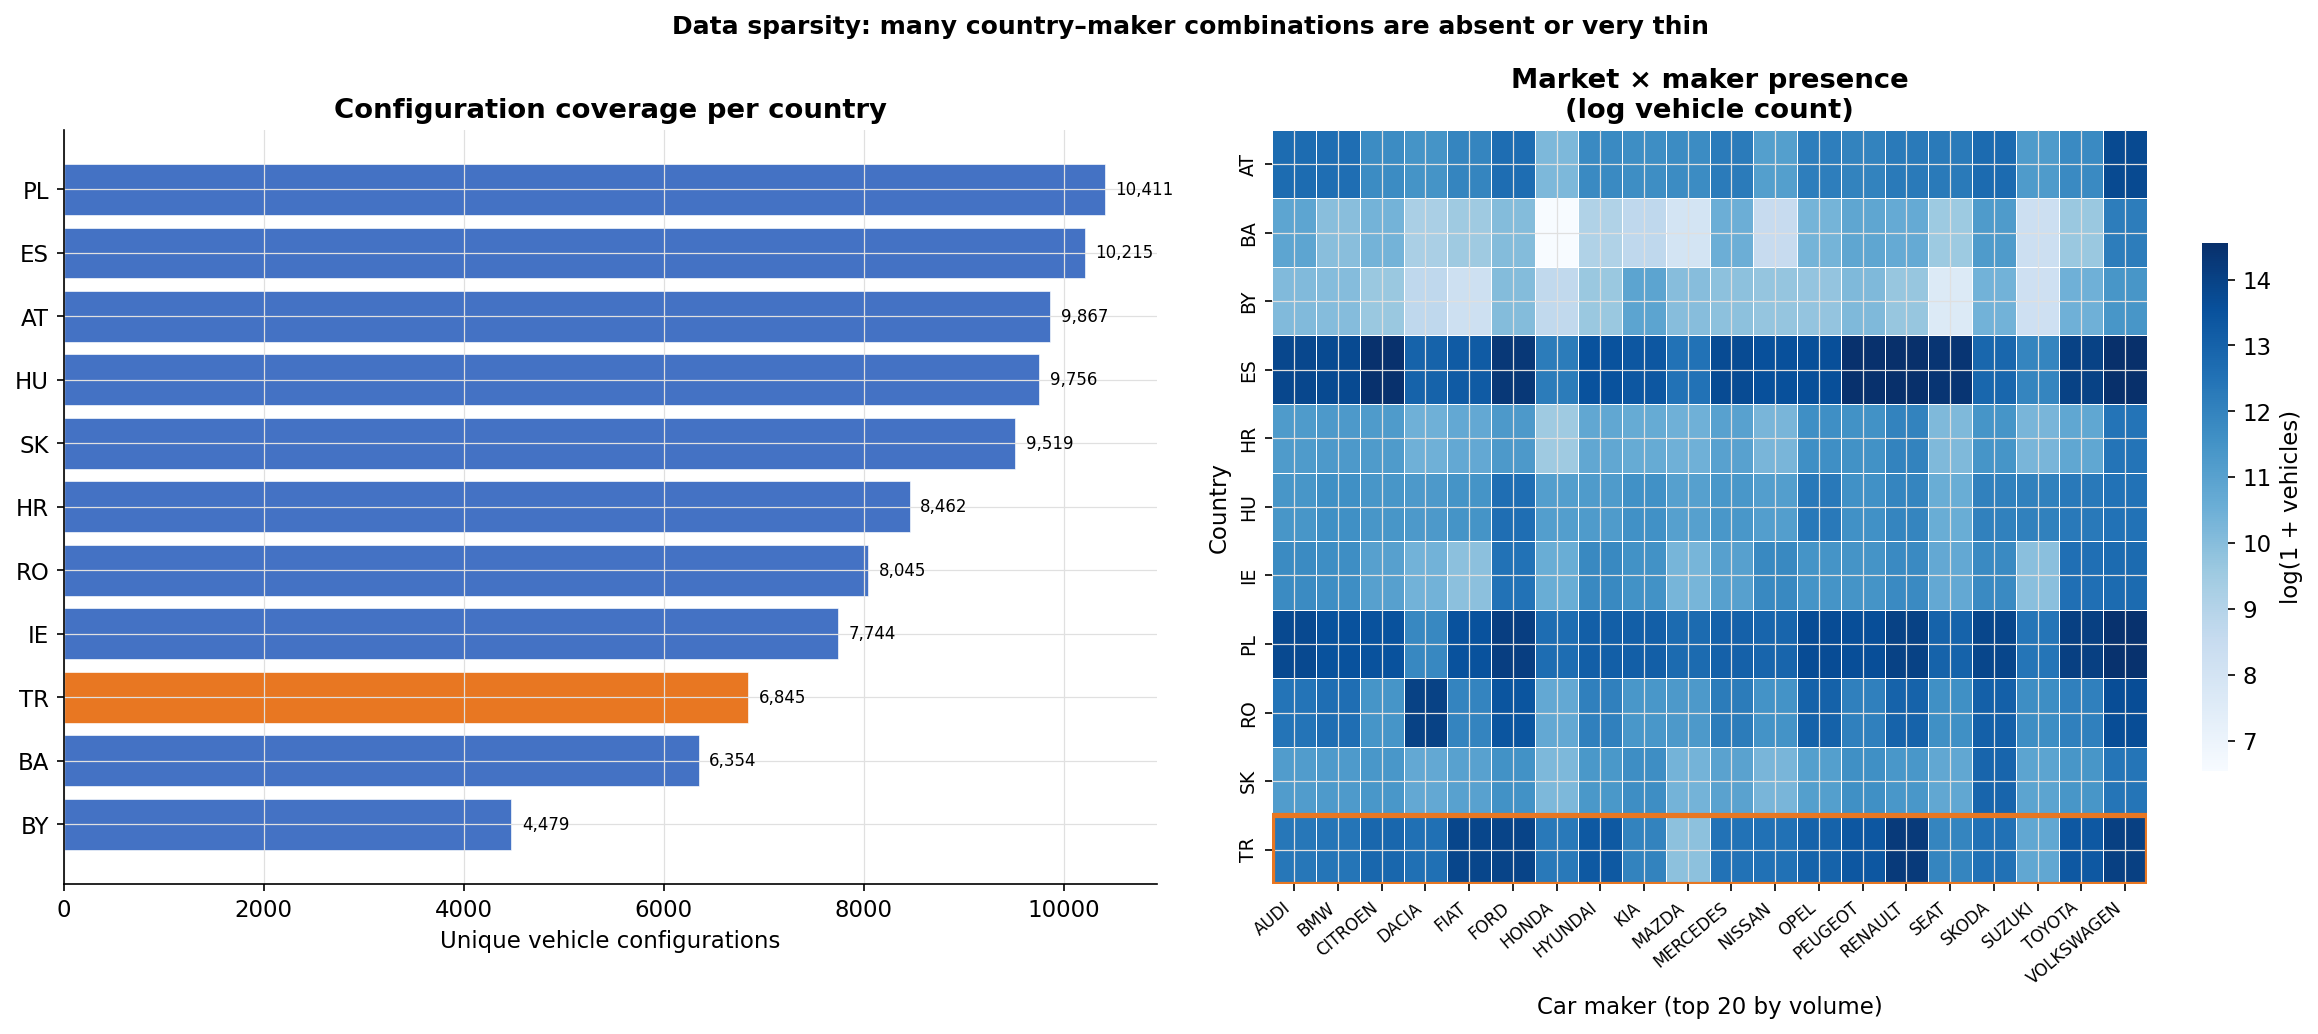

In [4]:
config_cols = ['car_maker_name', 'car_segment_name', 'car_type_name', 'energy', 'body_style', 'code_age']

# Unique configs per country
unique_configs = (train.groupby('country_iso')
                  .apply(lambda df: df[config_cols].drop_duplicates().shape[0])
                  .sort_values(ascending=True))

# Car maker × country presence matrix (top 20 makers)
top_makers = (train.groupby('car_maker_name')['total_vehicles']
              .sum().sort_values(ascending=False).head(20).index.tolist())
maker_matrix = (
    train[train['car_maker_name'].isin(top_makers)]
    .groupby(['country_iso', 'car_maker_name'])['total_vehicles']
    .sum().unstack(fill_value=0)
)
# Normalise to log scale for display
maker_matrix_log = np.log1p(maker_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — unique configs per country
ax = axes[0]
colors_uc = bar_colors(unique_configs.index)
bars = ax.barh(unique_configs.index, unique_configs.values,
               color=colors_uc, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Unique vehicle configurations')
ax.set_title('Configuration coverage per country', fontweight='bold')
# Add value labels
for bar, val in zip(bars, unique_configs.values):
    ax.text(bar.get_width() + unique_configs.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)

# Right — heatmap
ax = axes[1]
sns.heatmap(maker_matrix_log, ax=ax, cmap='Blues', linewidths=0.3,
            cbar_kws={'label': 'log(1 + vehicles)', 'shrink': 0.7},
            yticklabels=True, xticklabels=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.set_xlabel('Car maker (top 20 by volume)')
ax.set_ylabel('Country')
ax.set_title('Market × maker presence\n(log vehicle count)', fontweight='bold')
# Highlight Turkey row
tr_row_idx = list(maker_matrix_log.index).index('TR') if 'TR' in maker_matrix_log.index else None
if tr_row_idx is not None:
    ax.add_patch(plt.Rectangle((0, tr_row_idx), len(top_makers), 1,
                                fill=False, edgecolor=TR_COLOR, lw=2.5, zorder=5))

fig.suptitle('Data sparsity: many country–maker combinations are absent or very thin',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR + 'data_sparsity.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 5) Cold-Start Proportion  ← Fig 4.3

Turkey test rows  : 254
Cold-start (unseen): 73 (28.7%)
Covered            : 181 (71.3%)
Saved: ../report/figures/cold_start_proportion.png


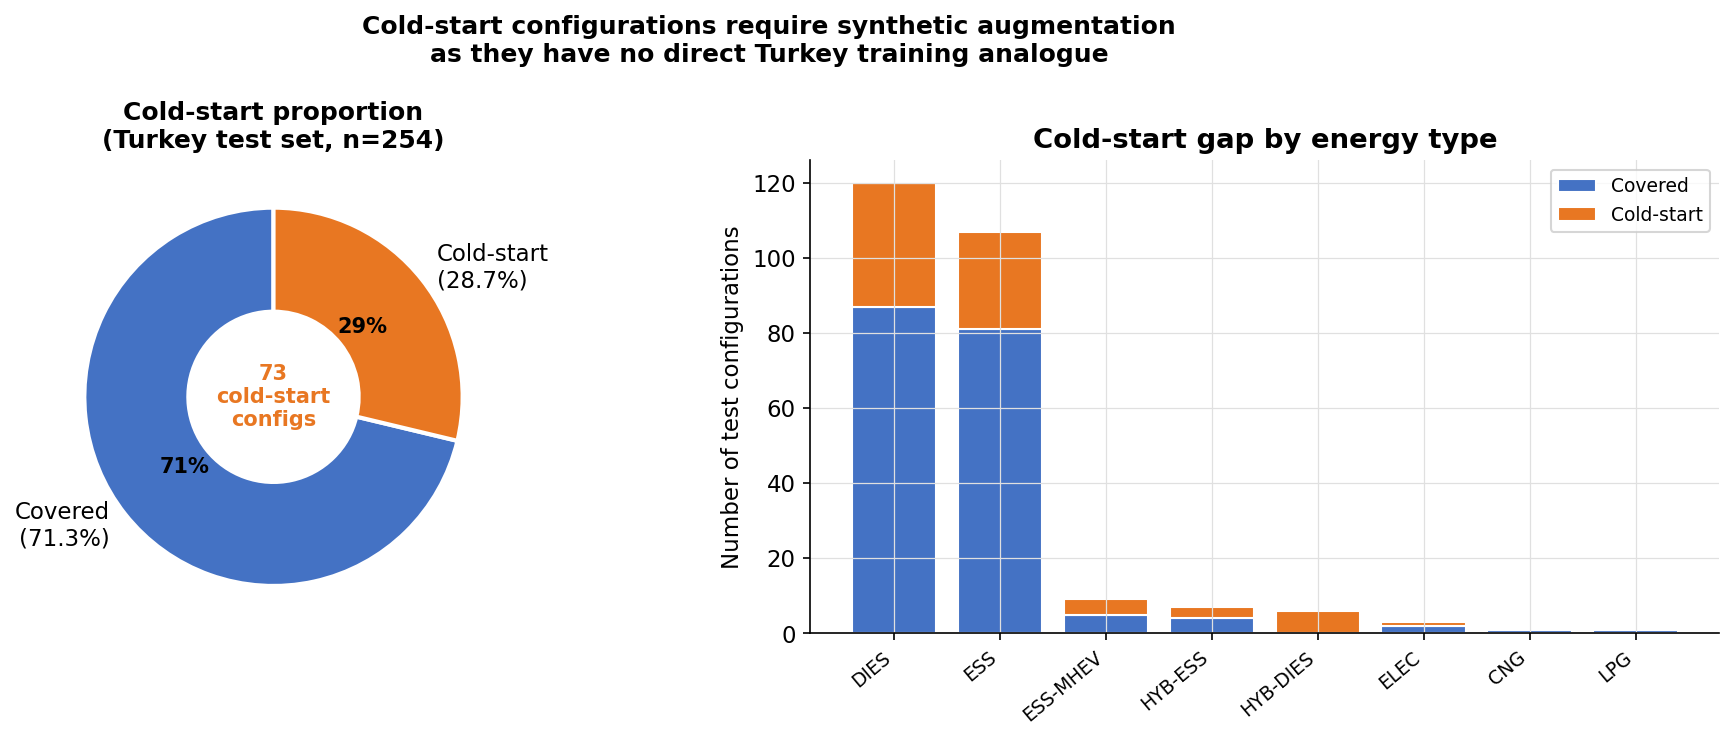

In [5]:
# Test configs
test_tr = test[test['country_iso'] == 'TR'].copy() if 'country_iso' in test.columns else test.copy()
if 'country_iso' not in test.columns:
    test_tr = test.copy()

# Turkey training configs (as frozen sets for fast membership)
tr_configs_train = set(
    tr[config_cols].apply(tuple, axis=1)
)
test_tr_configs  = test_tr[config_cols].apply(tuple, axis=1) if all(c in test_tr.columns for c in config_cols) else pd.Series([])

# Cold-start = test config NOT seen in Turkey training data
if len(test_tr_configs) > 0:
    is_cold   = ~test_tr_configs.isin(tr_configs_train)
    n_cold    = is_cold.sum()
    n_covered = (~is_cold).sum()
    n_total   = len(test_tr_configs)
    cold_pct  = n_cold / n_total * 100
else:
    # Test set has no country_iso — compute from all unique configs in test vs train
    all_test_configs  = set(test[config_cols].apply(tuple, axis=1))
    n_cold    = len(all_test_configs - tr_configs_train)
    n_covered = len(all_test_configs & tr_configs_train)
    n_total   = len(all_test_configs)
    cold_pct  = n_cold / n_total * 100

print(f'Turkey test rows  : {n_total}')
print(f'Cold-start (unseen): {n_cold} ({cold_pct:.1f}%)')
print(f'Covered            : {n_covered} ({100-cold_pct:.1f}%)')

# Cold-start by energy type (if available)
if len(test_tr_configs) > 0 and 'energy' in test_tr.columns:
    cold_mask = ~test_tr_configs.isin(tr_configs_train)
    cold_by_energy   = test_tr[cold_mask]['energy'].value_counts()
    covered_by_energy = test_tr[~cold_mask]['energy'].value_counts()
else:
    cold_by_energy   = pd.Series(dtype=int)
    covered_by_energy = pd.Series(dtype=int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — donut chart
ax = axes[0]
sizes  = [n_covered, n_cold]
labels = [f'Covered\n({100-cold_pct:.1f}%)', f'Cold-start\n({cold_pct:.1f}%)']
colors = [EU_COLOR, TR_COLOR]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title(f'Cold-start proportion\n(Turkey test set, n={n_total})',
             fontweight='bold', fontsize=12)
ax.text(0, 0, f'{n_cold}\ncold-start\nconfigs',
        ha='center', va='center', fontsize=10, fontweight='bold', color=TR_COLOR)

# Right — cold-start by energy type
ax = axes[1]
if len(cold_by_energy) > 0:
    energy_order = cold_by_energy.add(covered_by_energy, fill_value=0).sort_values(ascending=False).index
    cold_vals   = cold_by_energy.reindex(energy_order, fill_value=0)
    covered_vals = covered_by_energy.reindex(energy_order, fill_value=0)
    x = range(len(energy_order))
    ax.bar(x, covered_vals.values, color=EU_COLOR, label='Covered', edgecolor='white')
    ax.bar(x, cold_vals.values, bottom=covered_vals.values, color=TR_COLOR,
           label='Cold-start', edgecolor='white')
    ax.set_xticks(list(x))
    ax.set_xticklabels(energy_order.tolist(), rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Number of test configurations')
    ax.set_title('Cold-start gap by energy type', fontweight='bold')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Energy breakdown not available\n(test set has no energy column)',
            ha='center', va='center', transform=ax.transAxes, fontsize=10)
    ax.set_title('Cold-start gap by energy type', fontweight='bold')

fig.suptitle('Cold-start configurations require synthetic augmentation\n'
             'as they have no direct Turkey training analogue',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR + 'cold_start_proportion.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 6) Segment × Energy Heatmap (Turkey only)  ← Fig 4.8

Saved: ../report/figures/segment_energy_heatmap.png


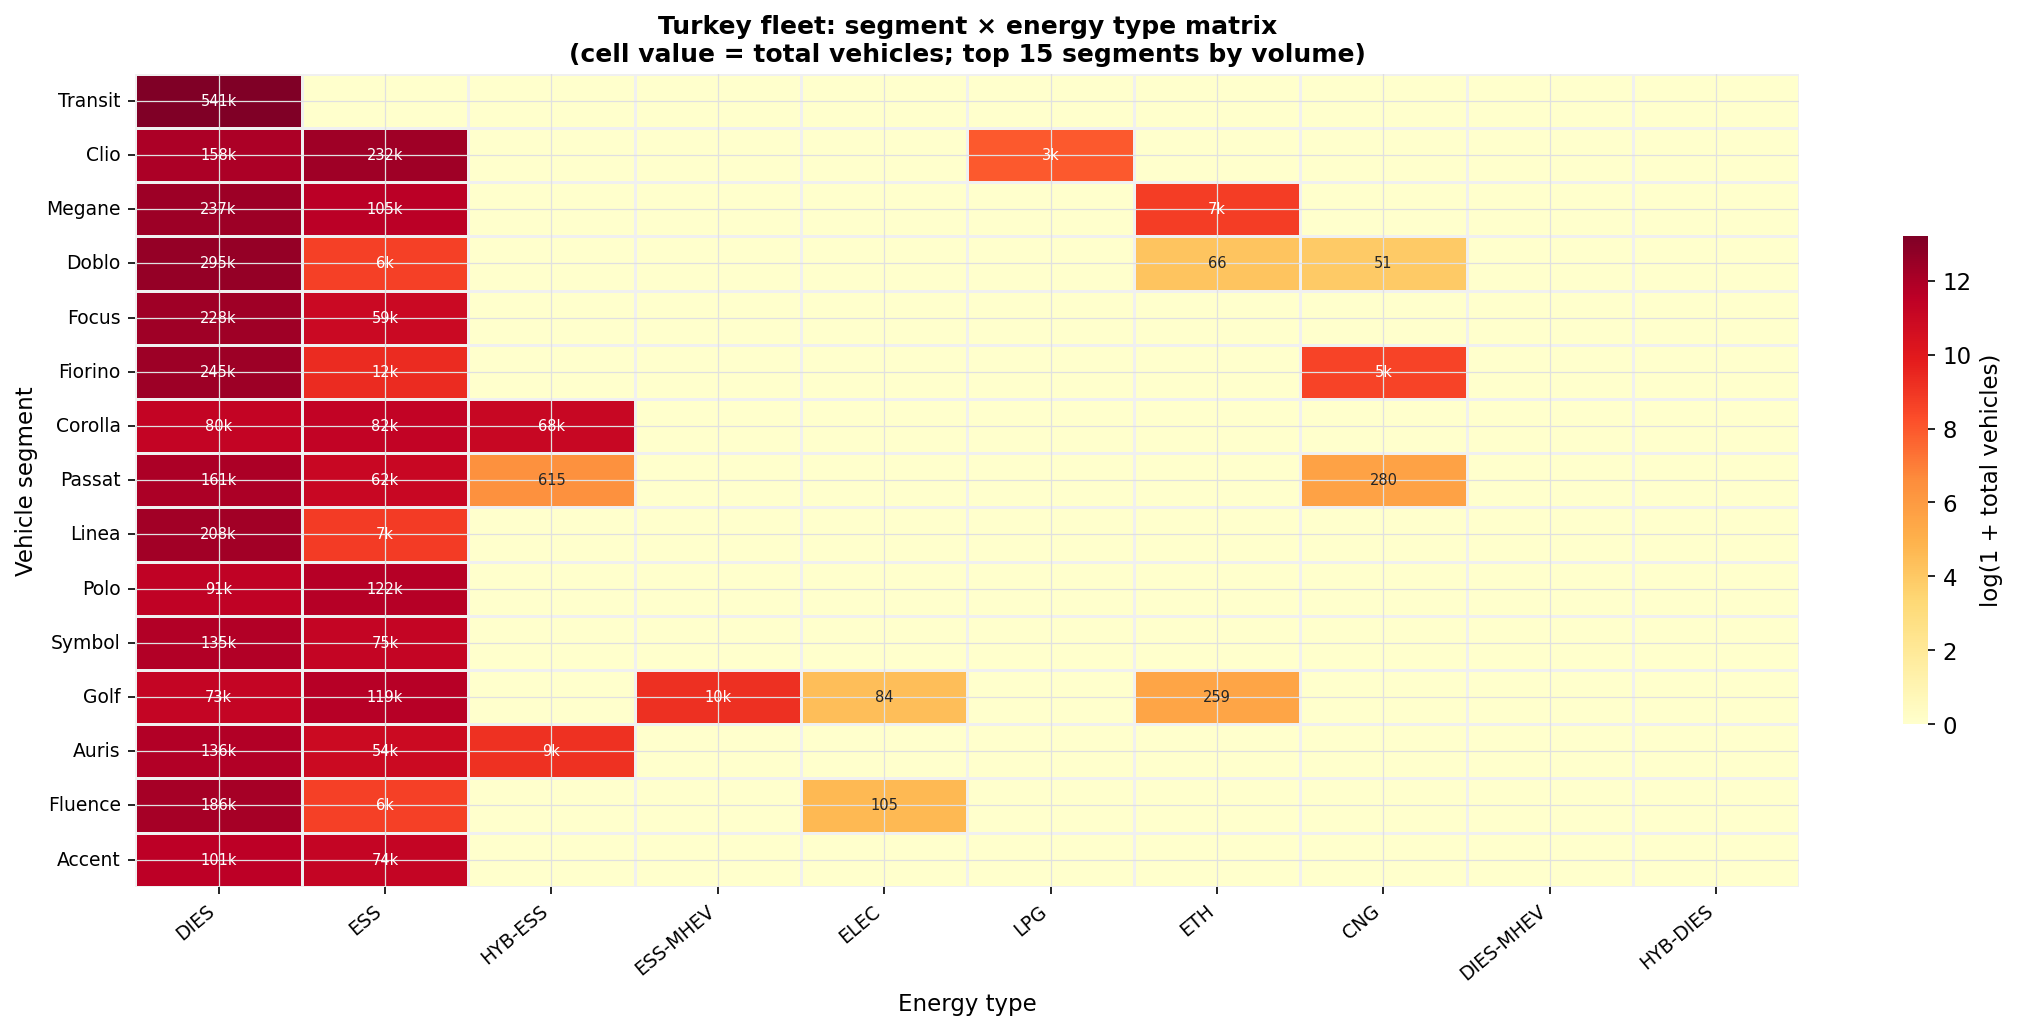

In [6]:
# Top 15 segments by volume in Turkey
top_segments = (tr.groupby('car_segment_name')['total_vehicles']
                .sum().sort_values(ascending=False)
                .head(15).index.tolist())

# All energy types
energy_order = (tr.groupby('energy')['total_vehicles']
                .sum().sort_values(ascending=False).index.tolist())

pivot = (
    tr[tr['car_segment_name'].isin(top_segments)]
    .groupby(['car_segment_name', 'energy'])['total_vehicles']
    .sum().unstack(fill_value=0)
    .reindex(columns=energy_order, fill_value=0)
)
# Sort segments by total descending
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

pivot_log = np.log1p(pivot)

def fmt_cell(v):
    if v >= 1000:
        return f'{v/1e3:.0f}k'
    elif v > 0:
        return str(int(v))
    return ''

annot_data = pivot.apply(lambda col: col.map(fmt_cell))

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(pivot_log, ax=ax, cmap='YlOrRd', linewidths=0.5, linecolor='#f0f0f0',
            cbar_kws={'label': 'log(1 + total vehicles)', 'shrink': 0.6},
            annot=annot_data, fmt='', annot_kws={'fontsize': 7})
ax.set_xlabel('Energy type', fontsize=11)
ax.set_ylabel('Vehicle segment', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Turkey fleet: segment × energy type matrix\n'
             '(cell value = total vehicles; top 15 segments by volume)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR + 'segment_energy_heatmap.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 7) Energy Mix: Stacked 100% Bar by Country

Saved: ../report/figures/energy_mix_comparison.png


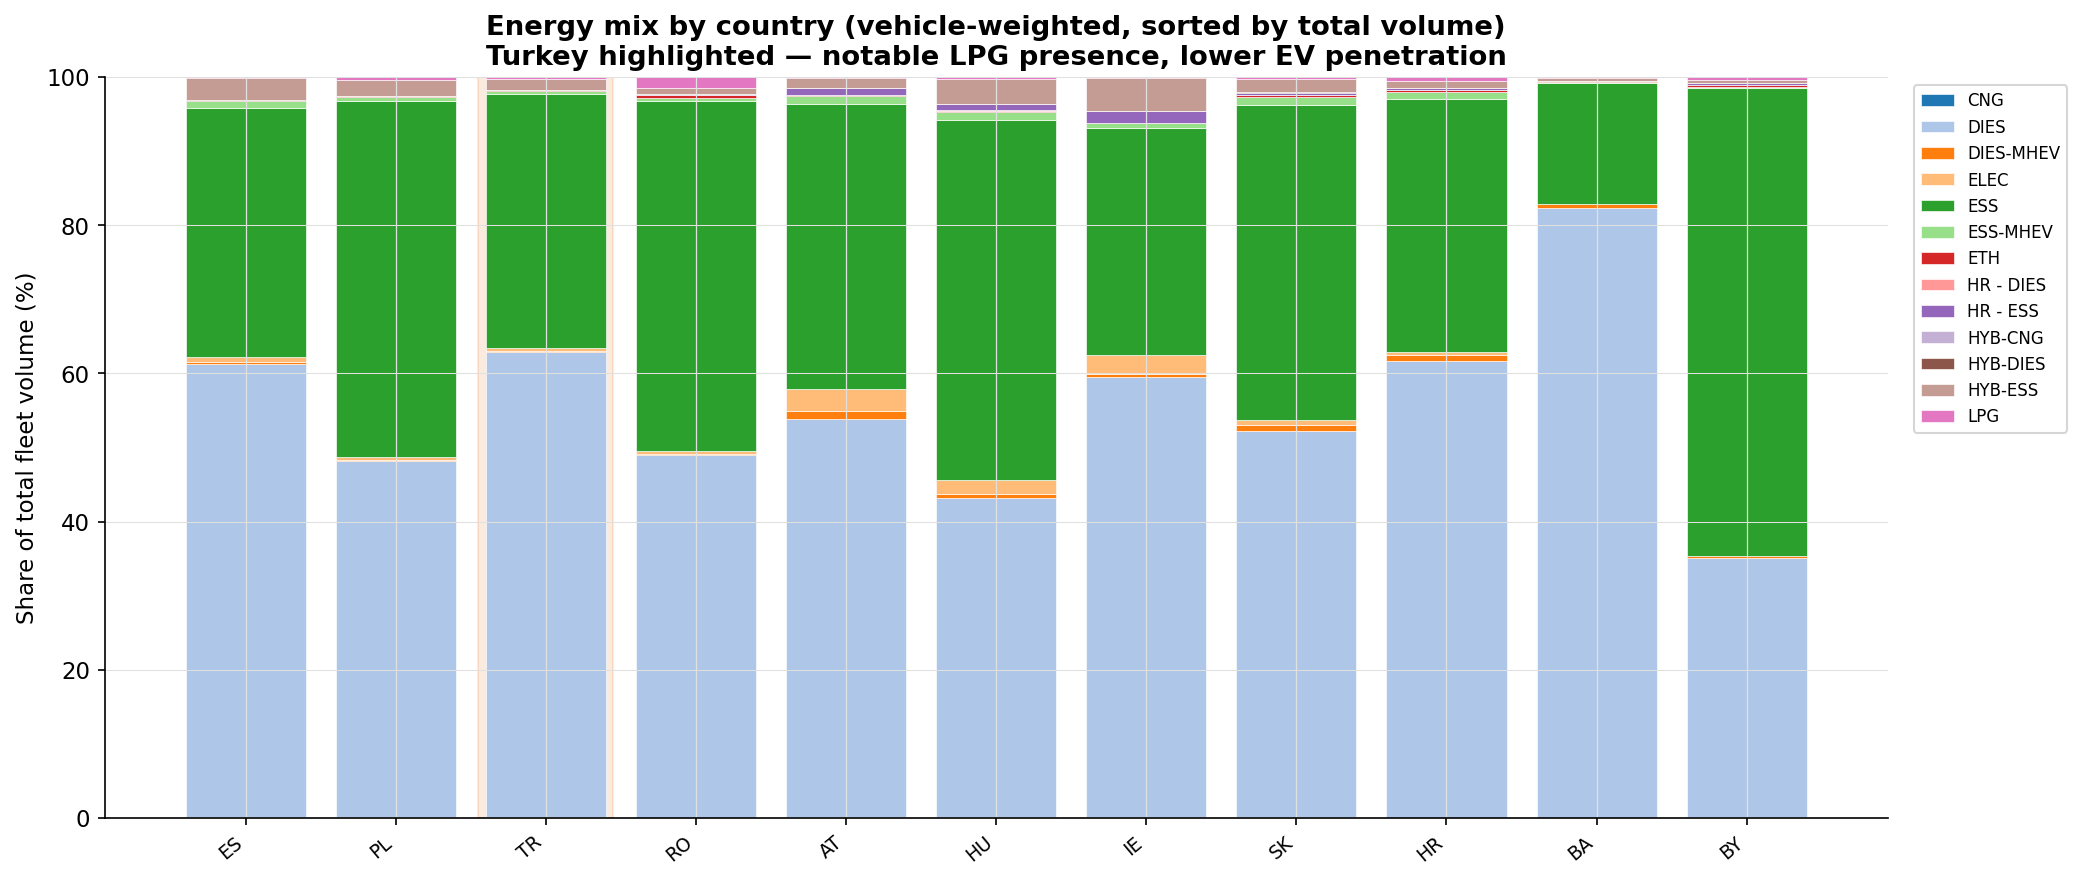

In [7]:
# Energy shares per country (vehicle-weighted)
energy_by_country = (
    train.groupby(['country_iso', 'energy'])['total_vehicles']
    .sum().unstack(fill_value=0)
)
energy_pct = energy_by_country.div(energy_by_country.sum(axis=1), axis=0) * 100

# Sort countries by total volume
country_order = energy_by_country.sum(axis=1).sort_values(ascending=False).index.tolist()
energy_pct    = energy_pct.loc[country_order]

# Color palette for energy types
n_energy  = len(energy_pct.columns)
palette   = sns.color_palette('tab20', n_energy)
energy_colors = dict(zip(energy_pct.columns, palette))

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(energy_pct))
x = range(len(energy_pct))

for energy_type in energy_pct.columns:
    vals = energy_pct[energy_type].values
    ax.bar(x, vals, bottom=bottom, label=energy_type,
           color=energy_colors[energy_type], edgecolor='white', linewidth=0.3)
    bottom += vals

ax.set_xticks(list(x))
ax.set_xticklabels(country_order, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Share of total fleet volume (%)')
ax.set_title('Energy mix by country (vehicle-weighted, sorted by total volume)\n'
             'Turkey highlighted — notable LPG presence, lower EV penetration',
             fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', linewidth=0.5)

# Highlight Turkey bar with outline
tr_idx = country_order.index('TR') if 'TR' in country_order else None
if tr_idx is not None:
    ax.axvspan(tr_idx - 0.45, tr_idx + 0.45, alpha=0.15, color=TR_COLOR, zorder=0)
    ax.annotate('Turkey', xy=(tr_idx, 102), ha='center', fontsize=9,
                fontweight='bold', color=TR_COLOR)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=True)
plt.tight_layout()
fname = FIG_DIR + 'energy_mix_comparison.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 8) EV / Hybrid Adoption by Country

Saved: ../report/figures/ev_adoption_by_country.png


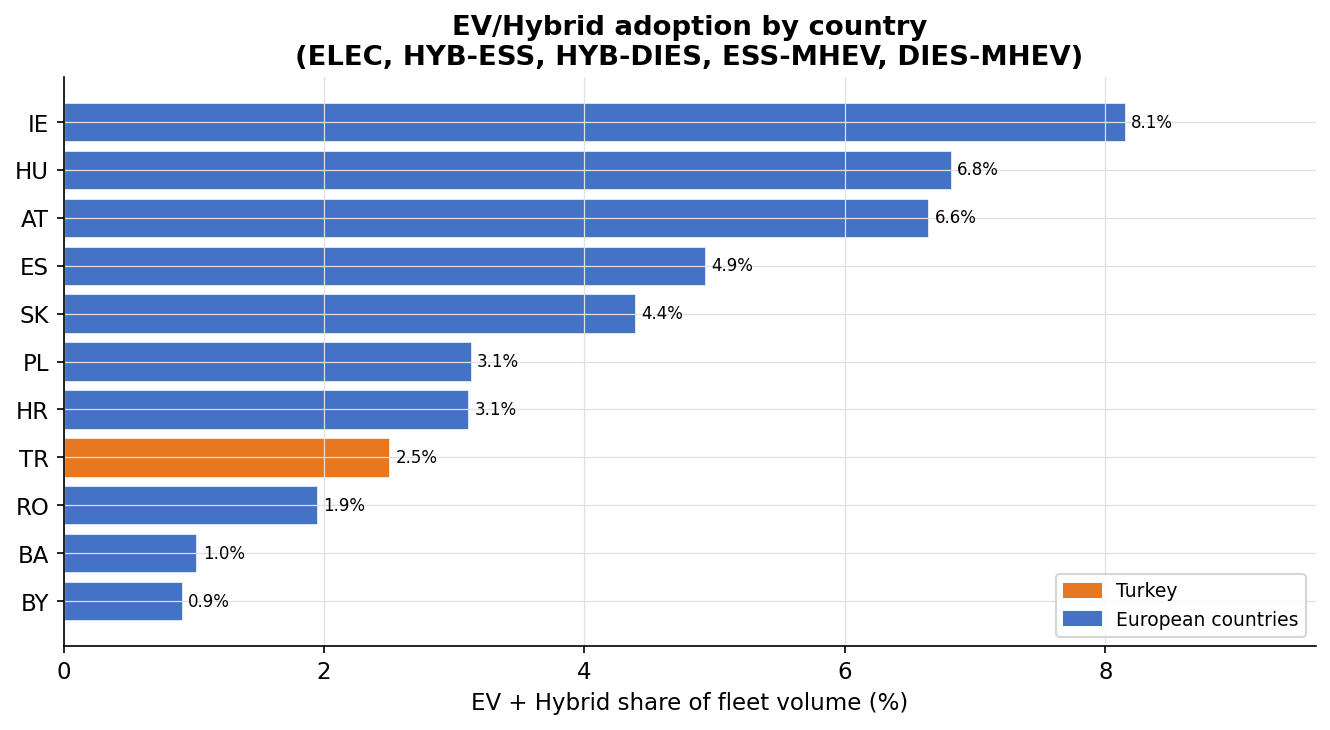

In [8]:
EV_TYPES = ['ELEC', 'HYB-ESS', 'HYB-DIES', 'ESS-MHEV', 'DIES-MHEV']

ev_share = []
for country, grp in train.groupby('country_iso'):
    total   = grp['total_vehicles'].sum()
    ev_vol  = grp[grp['energy'].isin(EV_TYPES)]['total_vehicles'].sum()
    ev_share.append({'country': country, 'ev_pct': ev_vol / total * 100 if total > 0 else 0})

ev_df = pd.DataFrame(ev_share).sort_values('ev_pct', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_ev = [TR_COLOR if c == 'TR' else EU_COLOR for c in ev_df['country']]
bars = ax.barh(ev_df['country'], ev_df['ev_pct'], color=colors_ev,
               edgecolor='white', linewidth=0.3)

# Value labels
for bar, val in zip(bars, ev_df['ev_pct']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('EV + Hybrid share of fleet volume (%)')
ax.set_title('EV/Hybrid adoption by country\n'
             '(ELEC, HYB-ESS, HYB-DIES, ESS-MHEV, DIES-MHEV)',
             fontweight='bold')
ax.set_xlim(0, ev_df['ev_pct'].max() * 1.18)

patches = [
    mpatches.Patch(color=TR_COLOR, label='Turkey'),
    mpatches.Patch(color=EU_COLOR, label='European countries'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
fname = FIG_DIR + 'ev_adoption_by_country.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 9) Fleet Age: Turkey vs Europe

Saved: ../report/figures/fleet_age_comparison.png


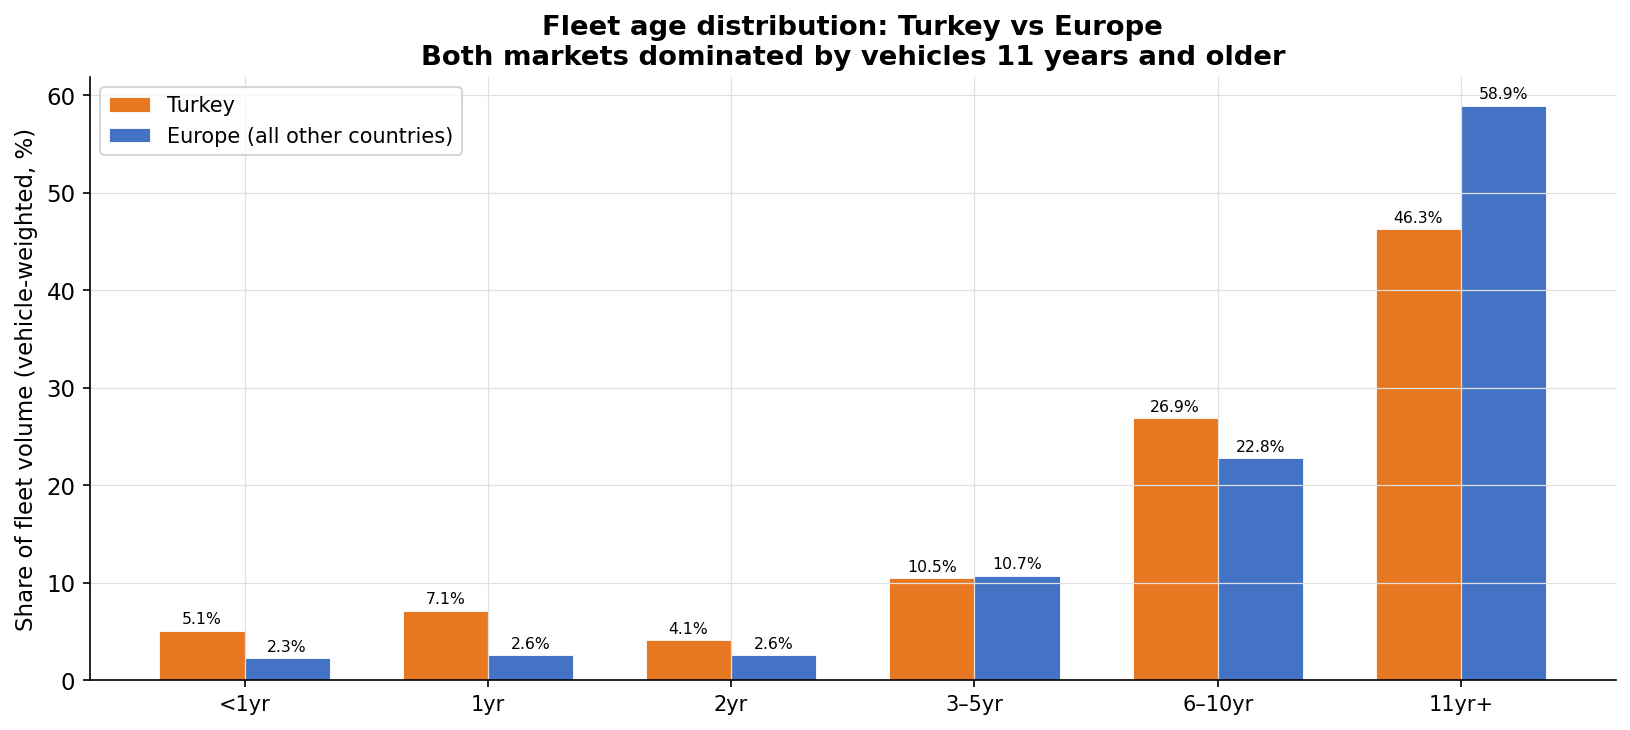

In [9]:

age_bins = [
    'Less than 1 year old',
    '1 year old',
    '2 years old',
    '3 to 5 years old',
    '6 to 10 years old',
    '11 years and older',
]

def age_shares(df):
    grp = df.groupby('code_age')['total_vehicles'].sum().reindex(age_bins, fill_value=0)
    return grp / grp.sum() * 100

tr_age = age_shares(tr)
eu_age = age_shares(eu)

x      = np.arange(len(age_bins))
width  = 0.35
labels_short = ['<1yr', '1yr', '2yr', '3–5yr', '6–10yr', '11yr+']

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, tr_age.values, width, label='Turkey', color=TR_COLOR,
            edgecolor='white', linewidth=0.4)
b2 = ax.bar(x + width/2, eu_age.values, width, label='Europe (all other countries)',
            color=EU_COLOR, edgecolor='white', linewidth=0.4)

# Value labels
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=10)
ax.set_ylabel('Share of fleet volume (vehicle-weighted, %)')
ax.set_title('Fleet age distribution: Turkey vs Europe\n'
             'Both markets dominated by vehicles 11 years and older',
             fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
fname = FIG_DIR + 'fleet_age_comparison.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 10) Country Similarity to Turkey (Cosine Similarity)

Cosine similarity to Turkey energy mix:
HR    0.999886
ES    0.999694
IE    0.997790
AT    0.991625
SK    0.982750
RO    0.964372
PL    0.959186
BA    0.953954
HU    0.939415
BY    0.844547
Saved: ../report/figures/country_similarity_turkey.png


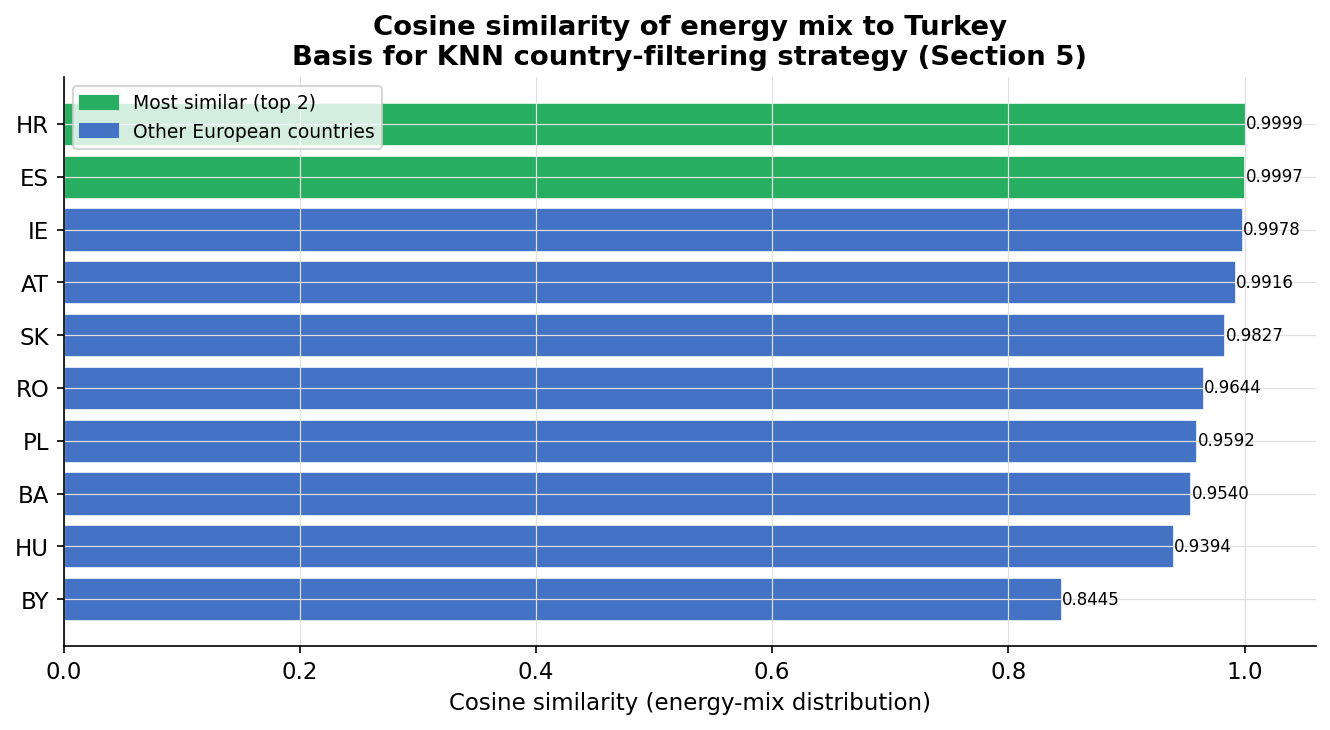

In [10]:
# Energy-mix vector per country
energy_vecs = (
    train.groupby(['country_iso', 'energy'])['total_vehicles']
    .sum().unstack(fill_value=0)
)
# Normalise to probability vectors
energy_probs = energy_vecs.div(energy_vecs.sum(axis=1), axis=0)

tr_vec = energy_probs.loc['TR'].values

similarity = {}
for country in energy_probs.index:
    if country == 'TR':
        continue
    vec = energy_probs.loc[country].values
    # cosine distance → similarity
    try:
        sim = 1.0 - cosine(tr_vec, vec)
    except Exception:
        sim = 0.0
    similarity[country] = sim

sim_series = pd.Series(similarity).sort_values(ascending=True)
print('Cosine similarity to Turkey energy mix:')
print(sim_series.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors_sim = [EU_COLOR] * len(sim_series)
# Top 2 most similar → highlight
top2 = sim_series.sort_values(ascending=False).head(2).index.tolist()
for i, c in enumerate(sim_series.index):
    if c in top2:
        colors_sim[i] = '#27AE60'   # green for most similar

bars = ax.barh(sim_series.index, sim_series.values, color=colors_sim,
               edgecolor='white', linewidth=0.3)

# Value labels
for bar, val in zip(bars, sim_series.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Cosine similarity (energy-mix distribution)')
ax.set_title('Cosine similarity of energy mix to Turkey\n'
             'Basis for KNN country-filtering strategy (Section 5)',
             fontweight='bold')
ax.set_xlim(0, 1.06)

patches = [
    mpatches.Patch(color='#27AE60', label='Most similar (top 2)'),
    mpatches.Patch(color=EU_COLOR,  label='Other European countries'),
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
fname = FIG_DIR + 'country_similarity_turkey.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 11) Top Vehicle Segments: Turkey vs Europe

Saved: ../report/figures/top_segments_turkey_vs_europe.png


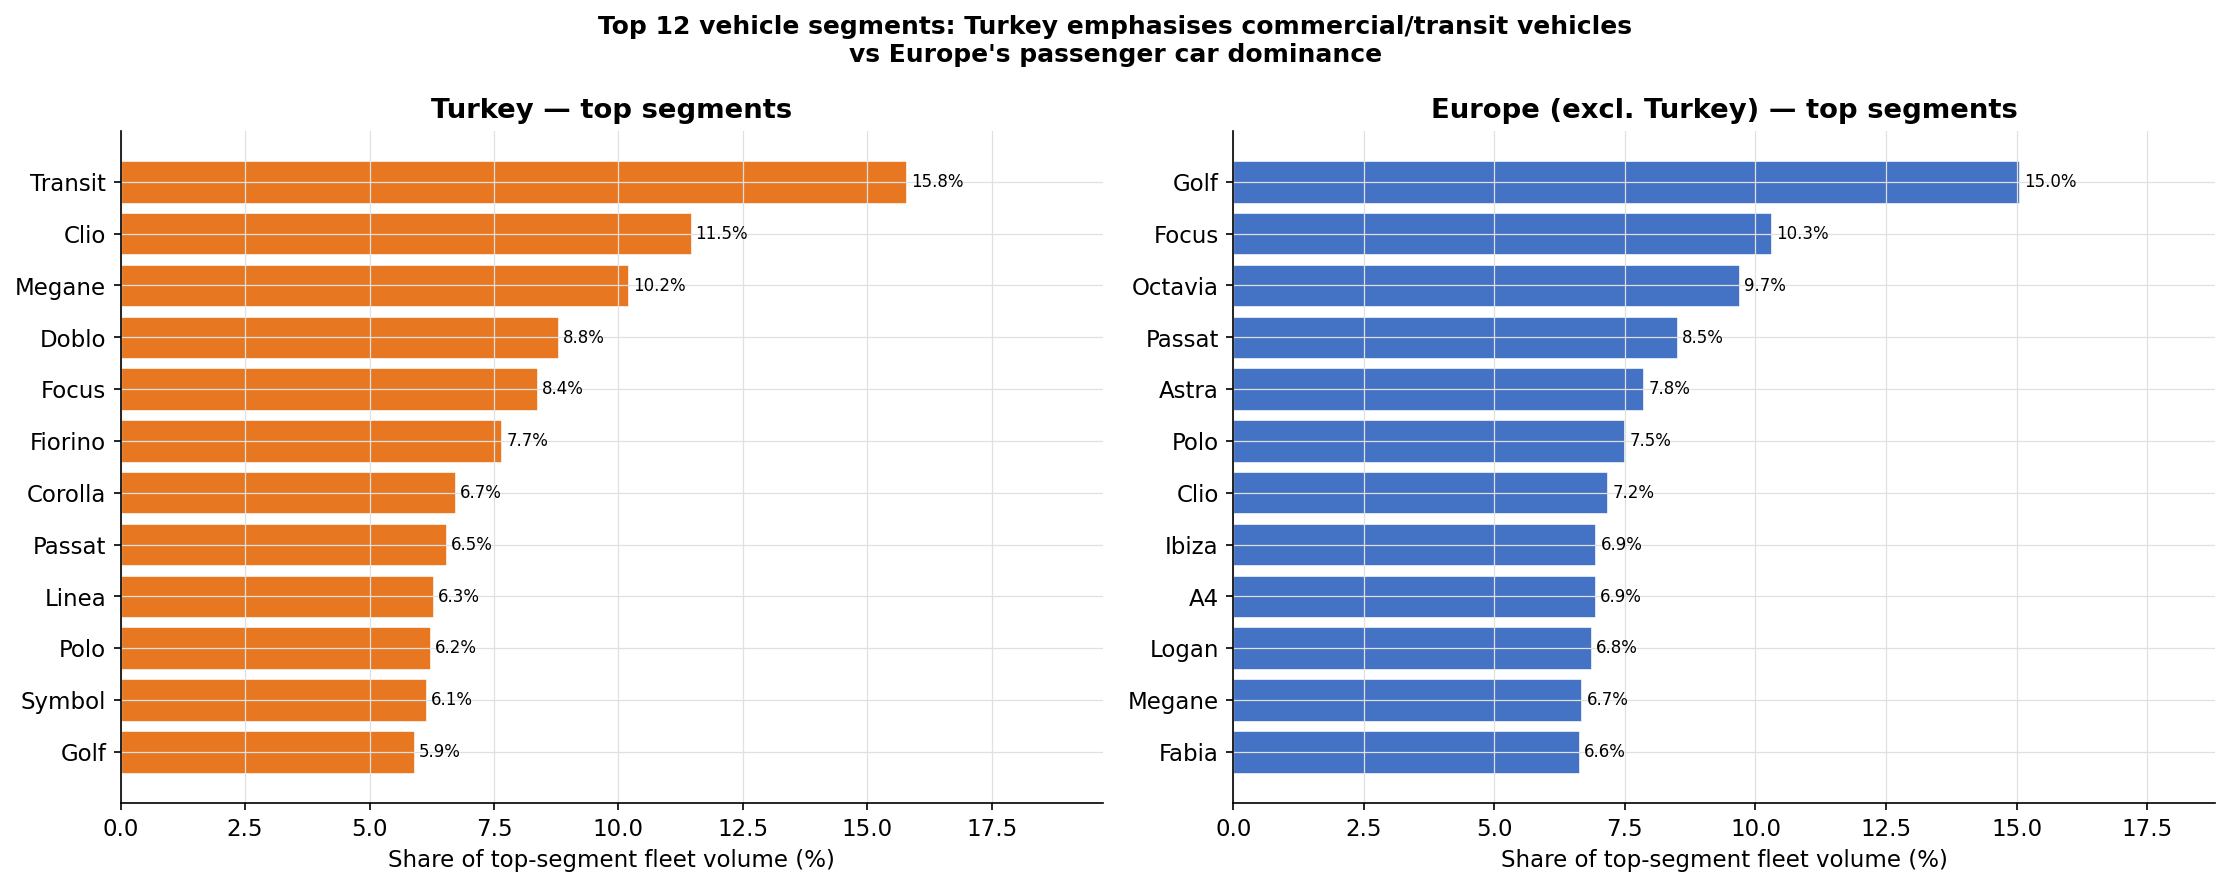

In [11]:
N_TOP = 12

tr_seg = (tr.groupby('car_segment_name')['total_vehicles']
          .sum().sort_values(ascending=False).head(N_TOP))
eu_seg = (eu.groupby('car_segment_name')['total_vehicles']
          .sum().sort_values(ascending=False).head(N_TOP))

# Normalize to shares (%)
tr_seg_pct = tr_seg / tr_seg.sum() * 100
eu_seg_pct = eu_seg / eu_seg.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, seg_pct, color, title in [
    (axes[0], tr_seg_pct, TR_COLOR, 'Turkey — top segments'),
    (axes[1], eu_seg_pct, EU_COLOR, 'Europe (excl. Turkey) — top segments'),
]:
    seg_sorted = seg_pct.sort_values(ascending=True)
    bars = ax.barh(seg_sorted.index, seg_sorted.values, color=color,
                   edgecolor='white', linewidth=0.3)
    for bar, val in zip(bars, seg_sorted.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.set_xlabel('Share of top-segment fleet volume (%)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, seg_sorted.max() * 1.25)

fig.suptitle(f'Top {N_TOP} vehicle segments: Turkey emphasises commercial/transit vehicles\n'
             'vs Europe\'s passenger car dominance',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fname = FIG_DIR + 'top_segments_turkey_vs_europe.png'
plt.savefig(fname, bbox_inches='tight', dpi=150)
print(f'Saved: {fname}')
plt.show()

## 12) Summary Statistics

In [12]:
print('=' * 60)
print('EDA SUMMARY STATISTICS')
print('=' * 60)
print(f'Total rows (after cleaning)  : {len(train):,}')
print(f'Turkey rows                  : {len(tr):,}')
print(f'European rows                : {len(eu):,}')
print(f'Countries                    : {train["country_iso"].nunique()}')
print(f'Unique car makers            : {train["car_maker_name"].nunique()}')
print(f'Unique energy types          : {train["energy"].nunique()}')
print(f'Unique configurations (train): {train[config_cols].drop_duplicates().shape[0]:,}')
print(f'Unique Turkey configs        : {tr[config_cols].drop_duplicates().shape[0]:,}')
print()
print('Target variable total_vehicles:')
print(f'  Skewness                   : {train["total_vehicles"].skew():.2f}')
print(f'  Median                     : {train["total_vehicles"].median():.0f}')
print(f'  Mean                       : {train["total_vehicles"].mean():.1f}')
print(f'  Max                        : {train["total_vehicles"].max():,}')
print(f'  % rows < 100 vehicles      : {(train["total_vehicles"] < 100).mean()*100:.1f}%')
tv = train['total_vehicles']
top1_share = tv[tv >= tv.quantile(0.99)].sum() / tv.sum() * 100
print(f'  Top 1% share of total vol  : {top1_share:.1f}%')
print()
print('Turkey top 5 brands by volume:')
top5 = tr.groupby('car_maker_name')['total_vehicles'].sum().sort_values(ascending=False).head(5)
total_tr_vol = tr['total_vehicles'].sum()
for brand, vol in top5.items():
    print(f'  {brand:<20s} {vol:>10,}  ({vol/total_tr_vol*100:.1f}%)')
print()
print('Cold-start analysis:')
print(f'  Turkey train configs        : {len(tr_configs_train):,}')
print(f'  Test cold-start configs     : {n_cold} / {n_total} ({cold_pct:.1f}%)')
print()
print('Country similarity to Turkey (top 3):')
for country, sim in sim_series.sort_values(ascending=False).head(3).items():
    print(f'  {country}  {sim:.4f}')
print('=' * 60)

EDA SUMMARY STATISTICS
Total rows (after cleaning)  : 91,697
Turkey rows                  : 6,845
European rows                : 84,852
Countries                    : 11
Unique car makers            : 63
Unique energy types          : 13
Unique configurations (train): 13,737
Unique Turkey configs        : 6,845

Target variable total_vehicles:
  Skewness                   : 18.55
  Median                     : 39
  Mean                       : 770.8
  Max                        : 254,061.0
  % rows < 100 vehicles      : 62.4%
  Top 1% share of total vol  : 36.0%

Turkey top 5 brands by volume:
  RENAULT              1,488,615.0  (14.5%)
  VOLKSWAGEN           1,278,714.0  (12.5%)
  FORD                 1,142,244.0  (11.1%)
  FIAT                 1,055,663.0  (10.3%)
  PEUGEOT               628,196.0  (6.1%)

Cold-start analysis:
  Turkey train configs        : 6,845
  Test cold-start configs     : 73 / 254 (28.7%)

Country similarity to Turkey (top 3):
  HR  0.9999
  ES  0.9997
  IE  0